In [2]:
import random
import numpy as np

# Predefined name parts
first_names = ['Aarav', 'Vivaan', 'Aditya', 'Rohan', 'Diya', 'Ishita', 'Meera', 'Tanvi', 'Pooja', 'Saanvi']
last_names = ['Sharma', 'Patel', 'Reddy', 'Mehta', 'Joshi', 'Nair', 'Desai', 'Verma', 'Iyer', 'Kapoor']

def generate_fake_name():
    return random.choice(first_names) + " " + random.choice(last_names)

def generate_fake_phone():
    return f"+91-9{random.randint(100000000, 999999999)}"


In [6]:
import pandas as pd

num_patients = 1500
patients = pd.DataFrame({
    'patient_id': range(1, num_patients + 1),
    'name': [generate_fake_name() for _ in range(num_patients)],
    'age': np.random.randint(20, 70, size=num_patients),
    'gender': np.random.choice(['Male', 'Female'], size=num_patients),
    'contact': [generate_fake_phone() for _ in range(num_patients)]
})

print(patients)


      patient_id          name  age  gender         contact
0              1   Aarav Verma   45    Male  +91-9222519565
1              2  Aditya Patel   28  Female  +91-9902839664
2              3  Vivaan Mehta   27    Male  +91-9441929556
3              4   Diya Sharma   59    Male  +91-9734553013
4              5    Rohan Iyer   23    Male  +91-9839724492
...          ...           ...  ...     ...             ...
1495        1496   Aarav Verma   44    Male  +91-9278545613
1496        1497  Pooja Kapoor   63    Male  +91-9921607909
1497        1498    Diya Verma   33    Male  +91-9102127535
1498        1499    Diya Verma   47  Female  +91-9942606960
1499        1500  Ishita Patel   23  Female  +91-9792774593

[1500 rows x 5 columns]


In [7]:
specializations = ['Cardiology', 'Dermatology', 'Neurology', 'Pediatrics', 'Orthopedics']

num_doctors = 60
doctors = pd.DataFrame({
    'doctor_id': range(1, num_doctors + 1),
    'name': [f"Dr. {generate_fake_name()}" for _ in range(num_doctors)],
    'specialization': np.random.choice(specializations, size=num_doctors),
    'availability': np.random.choice([True, False], size=num_doctors)
})

doctors.head()


,doctor_id,name,specialization,availability
0,1,Dr. Tanvi Kapoor,Dermatology,False
1,2,Dr. Vivaan Kapoor,Cardiology,True
2,3,Dr. Diya Desai,Orthopedics,False
3,4,Dr. Vivaan Nair,Neurology,False
4,5,Dr. Meera Iyer,Cardiology,True


In [9]:
# 3. Generate Appointments
num_appointments = 3000
appointments = pd.DataFrame({
    'appointment_id': range(1, num_appointments + 1),
    'patient_id': np.random.choice(patients['patient_id'], num_appointments),
    'doctor_id': np.random.choice(doctors['doctor_id'], num_appointments),
    'appointment_date': pd.to_datetime(np.random.choice(pd.date_range('2024-12-01', '2025-03-31'), size=num_appointments)),
    'status': np.random.choice(['Completed', 'Cancelled'], size=num_appointments)
})

print(appointments)

      appointment_id  patient_id  doctor_id appointment_date     status
0                  1        1125         43       2025-03-13  Cancelled
1                  2        1170         44       2025-03-30  Completed
2                  3         539         30       2025-01-25  Completed
3                  4        1215         22       2025-03-16  Completed
4                  5        1123         46       2025-02-11  Completed
...              ...         ...        ...              ...        ...
2995            2996         230         58       2025-02-27  Completed
2996            2997         626         19       2025-03-30  Cancelled
2997            2998         252         59       2025-03-16  Completed
2998            2999        1415         57       2025-03-05  Cancelled
2999            3000        1110          4       2025-01-19  Cancelled

[3000 rows x 5 columns]


In [16]:
# Merging Appointment with Patient & Doctor Data
# We merge the appointments dataset with patient and doctor data to create a detailed view, including patient names, doctor specializations, and appointment status.
appointments_with_details = appointments.merge(patients, on='patient_id', how='left')\
                                         .merge(doctors, on='doctor_id', how='left')

# Display merged appointments data
appointments_with_details.head()

,appointment_id,patient_id,doctor_id,appointment_date,status,month,name_x,age,gender,contact,name_y,specialization,availability
0,1,1125,43,2024-12-26,Cancelled,2024-12,Saanvi Mehta,65,Male,+91-9769533574,Dr. Pooja Reddy,Pediatrics,False
1,2,1170,44,2025-03-27,Completed,2025-03,Vivaan Kapoor,64,Female,+91-9147711322,Dr. Vivaan Sharma,Orthopedics,True
2,3,539,30,2025-01-15,Completed,2025-01,Vivaan Reddy,44,Female,+91-9264337033,Dr. Aditya Desai,Neurology,True
3,4,1215,22,2024-12-04,Completed,2024-12,Diya Reddy,53,Female,+91-9368841124,Dr. Diya Sharma,Dermatology,True
4,5,1123,46,2025-03-19,Completed,2025-03,Aditya Kapoor,24,Male,+91-9922196439,Dr. Vivaan Nair,Dermatology,True


In [17]:
# Data Cleaning
# In this step, we clean the data by:
# Ensuring the appointment date is properly converted to datetime.
# Filling any missing values with 'N/A' using the fillna() function.

# Data Cleaning: Handling Missing Data and Correct Data Types
appointments_with_details['appointment_date'] = pd.to_datetime(appointments_with_details['appointment_date'])

# Handling missing values
appointments_with_details.fillna('N/A', inplace=True)

# Display cleaned data
appointments_with_details.head()


,appointment_id,patient_id,doctor_id,appointment_date,status,month,name_x,age,gender,contact,name_y,specialization,availability
0,1,1125,43,2024-12-26,Cancelled,2024-12,Saanvi Mehta,65,Male,+91-9769533574,Dr. Pooja Reddy,Pediatrics,False
1,2,1170,44,2025-03-27,Completed,2025-03,Vivaan Kapoor,64,Female,+91-9147711322,Dr. Vivaan Sharma,Orthopedics,True
2,3,539,30,2025-01-15,Completed,2025-01,Vivaan Reddy,44,Female,+91-9264337033,Dr. Aditya Desai,Neurology,True
3,4,1215,22,2024-12-04,Completed,2024-12,Diya Reddy,53,Female,+91-9368841124,Dr. Diya Sharma,Dermatology,True
4,5,1123,46,2025-03-19,Completed,2025-03,Aditya Kapoor,24,Male,+91-9922196439,Dr. Vivaan Nair,Dermatology,True


In [10]:
# 4. Diagnoses
diagnoses = pd.DataFrame({
    'diagnosis_id': range(1, num_appointments + 1),
    'appointment_id': appointments['appointment_id'],
    'symptoms': np.random.choice(['Fever', 'Cough', 'Chest Pain', 'Skin Rash', 'Headache'], size=num_appointments),
    'diagnosis': np.random.choice(['Flu', 'Allergy', 'Infection', 'Hypertension'], size=num_appointments),
    'prescription': np.random.choice(['Paracetamol', 'Antibiotic', 'Antihistamine', 'Painkiller'], size=num_appointments)
})

print(diagnoses)

      diagnosis_id  appointment_id    symptoms     diagnosis   prescription
0                1               1       Fever       Allergy  Antihistamine
1                2               2   Skin Rash  Hypertension     Painkiller
2                3               3   Skin Rash       Allergy  Antihistamine
3                4               4       Fever           Flu    Paracetamol
4                5               5  Chest Pain       Allergy    Paracetamol
...            ...             ...         ...           ...            ...
2995          2996            2996    Headache     Infection     Painkiller
2996          2997            2997       Fever           Flu  Antihistamine
2997          2998            2998    Headache     Infection  Antihistamine
2998          2999            2999  Chest Pain       Allergy    Paracetamol
2999          3000            3000    Headache     Infection    Paracetamol

[3000 rows x 5 columns]


In [11]:
# 5. Billing
billing = pd.DataFrame({
    'bill_id': range(1, num_appointments + 1),
    'appointment_id': appointments['appointment_id'],
    'amount': np.round(np.random.uniform(150.0, 1200.0, size=num_appointments), 2),
    'payment_status': np.random.choice(['Paid', 'Pending'], size=num_appointments)
})

print(billing)

      bill_id  appointment_id  amount payment_status
0           1               1  165.28        Pending
1           2               2  423.46           Paid
2           3               3  988.21        Pending
3           4               4  679.43           Paid
4           5               5  407.52           Paid
...       ...             ...     ...            ...
2995     2996            2996  225.88        Pending
2996     2997            2997  469.24        Pending
2997     2998            2998  936.42        Pending
2998     2999            2999  568.72        Pending
2999     3000            3000  741.24        Pending

[3000 rows x 4 columns]


In [18]:
# Revenue Calculation
# We generate billing data (appointment costs) and merge it with the appointments data to calculate total revenue for each month. The revenue is aggregated by month using the groupby() function.
# Merge billing data with appointments
revenue_data = appointments.merge(billing, on='appointment_id')

# Extract month and calculate total revenue by month
revenue_data['month'] = revenue_data['appointment_date'].dt.to_period('M')
monthly_revenue = revenue_data.groupby('month')['amount'].sum().reset_index()

monthly_revenue['month'] = monthly_revenue['month'].astype(str)

# Display monthly revenue data
monthly_revenue.head()

,month,amount
0,2024-10,367358.47
1,2024-11,330827.94
2,2024-12,343722.28
3,2025-01,332135.50
4,2025-02,302851.81


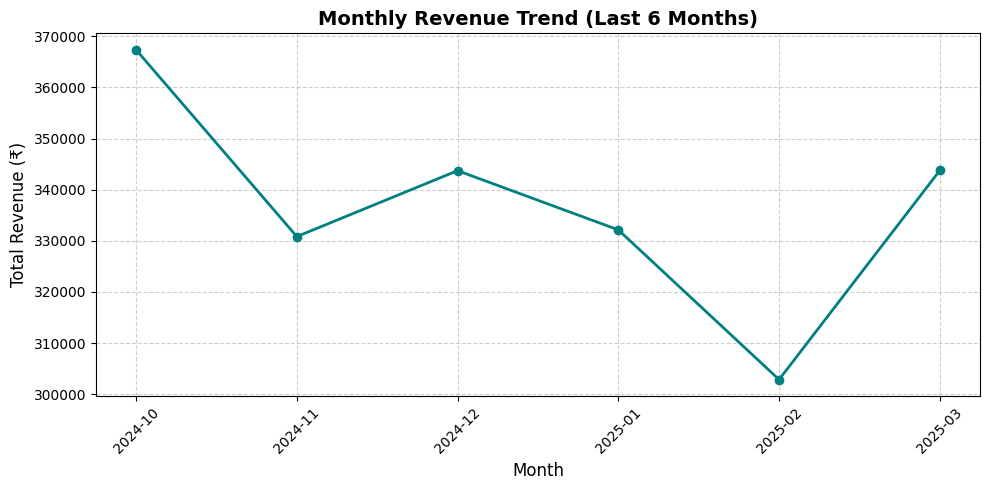

In [19]:
# Data Visualization
# Here, we use Matplotlib to create a line plot showing the monthly revenue trend for the last 6 months. This visualization helps to identify patterns and fluctuations in revenue over time.
# Visualizing the Monthly Revenue Trend (Last 6 Months)
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['amount'], marker='o', color='teal', linewidth=2)

plt.title('Monthly Revenue Trend (Last 6 Months)', fontsize=14, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [20]:
# Statistical Summary
# Using the describe() function, we generate summary statistics (e.g., mean, median, and standard deviation) for the revenue amounts, giving a deeper insight into the distribution of the data.
# Statistical Summary: Descriptive Statistics
revenue_data['amount'].describe()


,amount
count,3000.000000
mean,673.554257
std,308.669829
min,150.150000
25%,397.480000
50%,674.565000
75%,947.447500
max,1199.930000


In [21]:
# Data Filtering
# In this step, we filter the appointments dataset to only show completed appointments using the status column. This is a common data filtering task in real-world data analysis.

# Filter data: Finding Completed Appointments
completed_appointments = appointments[appointments['status'] == 'Completed']

# Display completed appointments
completed_appointments.head()


,appointment_id,patient_id,doctor_id,appointment_date,status,month
1,2,1170,44,2025-03-27,Completed,2025-03
2,3,539,30,2025-01-15,Completed,2025-01
3,4,1215,22,2024-12-04,Completed,2024-12
4,5,1123,46,2025-03-19,Completed,2025-03
5,6,737,56,2025-03-24,Completed,2025-03
